## **D. Semantic Chunking**

### What is it?
- Semantic chunking creates chunks based on the meaning and
semantic similarity of the text rather than arbitrary size limits. 
- It starts with an initial chunk and keeps adding sentences as long
as they remain semantically similar (measured by cosine
similarity of embeddings). When similarity drops below a
threshold, a new chunk begins.
- This is like grouping related topics in a conversation - you keep
talking about one subject until the topic naturally shifts.



> ### Advantages:
- Preserves semantic coherence within chunks
- More intelligent splitting based on meaning
- Better retrieval performance in RAG applications
- Natural topic boundaries
- Improved context preservation

> ### Disadvantages:
- Computationaily expensive (requires embeddings i.e.API calls for every sentence)
- Variable chunk sizes can be problematic
- Slower processing time
- Requires an embedding model
- May create very large or very small chunks
- Difficult to predict chunk count in advance

#### **Using Cosine Similarity between Embedding Vectors to identify the Semantic Similarity between any 2 text strings**

<div style="width: 1000px; height: 500px">

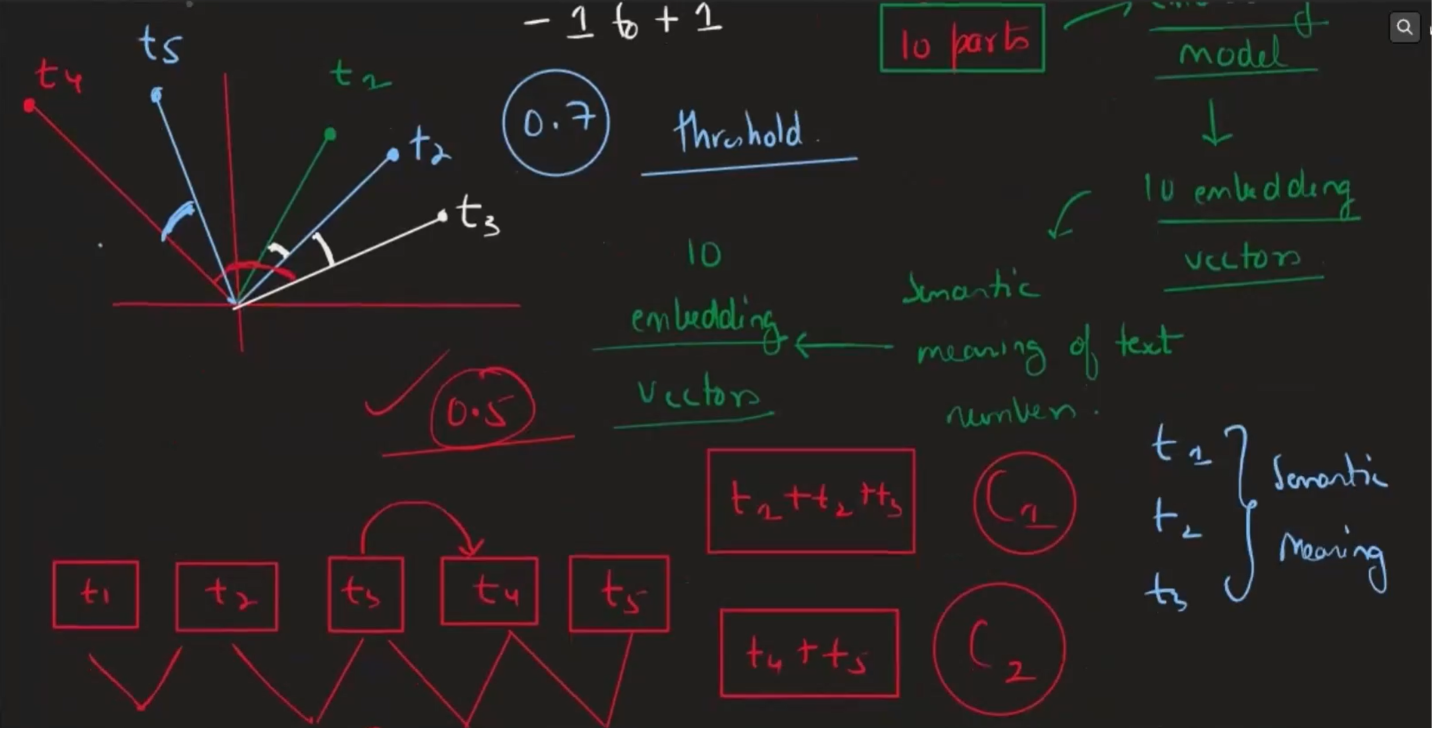

</div>

In [32]:
from langchain_experimental.text_splitter import SemanticChunker
from langchain_google_genai import GoogleGenerativeAIEmbeddings
from dotenv import load_dotenv 
import os

In [33]:
# load the env vars
load_dotenv(dotenv_path="../../.env")
# print("Key loaded:", bool(os.getenv("GOOGLE_API_KEY")))

True

In [34]:
text = """Artificial intelligence is transforming technology and shaping the future.
Machine learning algorithms are becoming more sophisticated every day.
Deep learning models can now process vast amounts of data efficiently.
Neural networks are inspired by the human brain's structule.
The best pasta recipes include fresh ingredients and proper cooking techniques.
Italian cuisine emphasizes quality olive oil and regional cheeses.
Authentic carbonara uses guanciale, eggs, pecorino romano, and black pepper.
Cooking pasta al dente ensures the best texture and flavor.
Climate change is affecting ecosystems worldwide.
Rising temperatures are causing glaciers to melt at unprecedented rates.
Scientists warn that immediate action is needed to reduce carbon emissions.
Renewable energy sources offer hope for a sustainable future. """

In [60]:
chunker= SemanticChunker(
    embeddings= GoogleGenerativeAIEmbeddings(model= "models/gemini-embedding-001"),
    breakpoint_threshold_type= "standard_deviation",   # OR "standard deviation" OR "interquartile"
    breakpoint_threshold_amount= 0.9
)

In [61]:
chunks= chunker.split_text(text)
print(f"Number of chunks: {len(chunks)}")
chunks

Number of chunks: 3


["Artificial intelligence is transforming technology and shaping the future. Machine learning algorithms are becoming more sophisticated every day. Deep learning models can now process vast amounts of data efficiently. Neural networks are inspired by the human brain's structule. The best pasta recipes include fresh ingredients and proper cooking techniques.",
 'Italian cuisine emphasizes quality olive oil and regional cheeses. Authentic carbonara uses guanciale, eggs, pecorino romano, and black pepper. Cooking pasta al dente ensures the best texture and flavor. Climate change is affecting ecosystems worldwide.',
 'Rising temperatures are causing glaciers to melt at unprecedented rates. Scientists warn that immediate action is needed to reduce carbon emissions. Renewable energy sources offer hope for a sustainable future. ']

In [66]:
from termcolor import COLORS, colored
from random import choice
from pprint import pp

def display_chunks(chunks: list[str], chunk_overlap: int=0):
    colors_list= list(COLORS.keys())[2:8]
    print(f"Number of Chunks: {len(chunks)}")
    for num, chunk in enumerate(chunks,1):
        print(f"Chunk {num}: Length of Characters: {len(chunk)}")
        print(colored(chunk, choice(colors_list)), end="\n")

display_chunks(chunks)

Number of Chunks: 3
Chunk 1: Length of Characters: 357
Artificial intelligence is transforming technology and shaping the future. Machine learning algorithms are becoming more sophisticated every day. Deep learning models can now process vast amounts of data efficiently. Neural networks are inspired by the human brain's structule. The best pasta recipes include fresh ingredients and proper cooking techniques.
Chunk 2: Length of Characters: 253
Italian cuisine emphasizes quality olive oil and regional cheeses. Authentic carbonara uses guanciale, eggs, pecorino romano, and black pepper. Cooking pasta al dente ensures the best texture and flavor. Climate change is affecting ecosystems worldwide.
Chunk 3: Length of Characters: 211
Rising temperatures are causing glaciers to melt at unprecedented rates. Scientists warn that immediate action is needed to reduce carbon emissions. Renewable energy sources offer hope for a sustainable future. 
